PCA on training TF-IDF dataset to reduce dimensionality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
data = pd.read_csv('TF-IDF_vectorised_tweets_no_names.csv')

In [2]:
from sklearn.decomposition import PCA
data.head


<bound method NDFrame.head of          0    1    2    3    4    5    6    7    8    9  ...  18632  18633  \
0      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
1      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
2      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
3      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
4      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
...    ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
11383  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
11384  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
11385  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
11386  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   
11387  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0   

       18634  18635  18636  18637

In [3]:
label = data['label']
data = data.drop(columns=['label'])

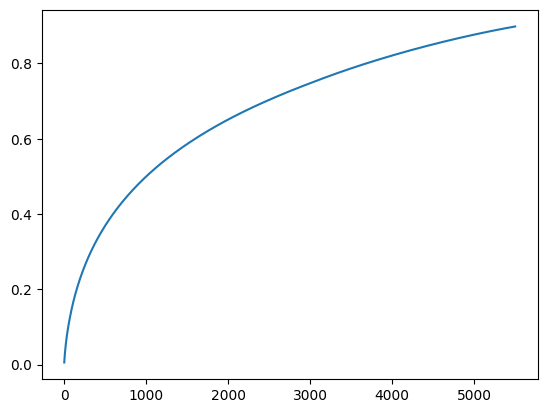

In [4]:
#ata = data.drop(columns=['label'])
n_components = 5500
pca = PCA(n_components=n_components)

# Fit the PCA model to the TF-IDF data
pca_result = pca.fit_transform(data)  
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# Plot cumulative variance to help you decide
#plt.xlabel('Principal component index')
#plt.ylabel('Cumulative variance explained')

#plot variance explained 
plt.plot(cumulative_variance)

In [7]:
explained_variance = pca.explained_variance_ratio_

x=5500
variance_explained_by_x_components = np.sum(explained_variance[:x])

print(f"Variance explained by the first {x} components: {variance_explained_by_x_components:.2f}")
##90% of variance in data is capture by 5500 features compared to 18642 total features, so can be reduced to 5500 and still have 90% of infomational value

Variance explained by the first 5500 components: 0.90


In [8]:
print(pca_result)

[[ 1.27436145e-01  2.57698556e-02 -5.93814672e-02 ... -1.92614101e-03
  -3.46707959e-03 -1.87667775e-03]
 [-5.85543141e-02 -4.70481513e-02  1.41828600e-03 ... -4.23690508e-04
   2.88345462e-03  1.92727727e-03]
 [-2.84999668e-02 -2.47161247e-03  1.57174487e-02 ... -1.18182101e-04
  -4.55940270e-04  1.80256461e-05]
 ...
 [-3.16928108e-02 -2.73030353e-03  1.46270523e-02 ... -2.79628187e-03
   4.30742495e-03  1.19847585e-02]
 [-7.90764320e-02 -3.82273536e-02 -9.62182742e-03 ... -6.90613986e-04
   7.56211815e-04 -3.40888100e-03]
 [ 6.79111435e-02  9.46876883e-02 -1.02713526e-01 ... -1.85164267e-05
  -5.20727765e-05 -1.88883230e-05]]


In [9]:
##saving pca_result as dataframe
pca_tfidf_tweet = pd.DataFrame(data=pca_result)

##append label
pca_tfidf_tweet['label'] = label

pca_tfidf_tweet.shape
pca_tfidf_tweet.head


<bound method NDFrame.head of               0         1         2         3         4         5         6  \
0      0.127436  0.025770 -0.059381 -0.020457  0.073275 -0.030781  0.017851   
1     -0.058554 -0.047048  0.001418 -0.027080  0.030506  0.199238  0.176999   
2     -0.028500 -0.002472  0.015717  0.009035 -0.030792 -0.017536  0.007595   
3     -0.060284 -0.021893  0.001392 -0.017845 -0.005146  0.014408 -0.066229   
4      0.026754  0.055901 -0.059645 -0.006999  0.036973 -0.036119  0.022901   
...         ...       ...       ...       ...       ...       ...       ...   
11383 -0.045758 -0.006790  0.026181  0.014521 -0.064001 -0.037014  0.018816   
11384 -0.059763 -0.020437  0.002987 -0.012408 -0.020782  0.056577 -0.004416   
11385 -0.031693 -0.002730  0.014627  0.009501 -0.031800 -0.017278  0.003050   
11386 -0.079076 -0.038227 -0.009622 -0.050124  0.006586  0.053741 -0.121501   
11387  0.067911  0.094688 -0.102714 -0.011758  0.081136 -0.048347  0.034230   

              7      

In [10]:
## save as csv 
pca_tfidf_tweet.to_csv('pca_tfidf_tweets_dataset1', index=False)